# Learning the Logical Channel from Syndrome Information

This notebook demonstrates the full pipeline for learning logical error probabilities from circuit-level syndrome data.

**Pipeline:**
1. **Build code** — construct a CSS code (rotated surface code)
2. **Syndrome extraction** — build a noisy stim circuit, sample detector/observable outcomes, extract the DEM
3. **Benchmark** — compare sampled LEP (direct Monte Carlo decoding) vs predicted LEP (from syndrome-learned priors)

In [2]:
import numpy as np
from bposd.css import css_code
from sim_qec.codes_family.hpc_lp import rotated_surface_code_checks
from sim_qec.pipeline import (
    SyndromeExtractionConfig,
    run_syndrome_extraction,
    benchmark_lep,
)
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

## Step 1: Build the CSS Code

We use the rotated surface code of distance $d$, constructed via `rotated_surface_code_checks` and wrapped in `bposd.css.css_code`.

In [3]:
d = 3
Hx, Hz = rotated_surface_code_checks(d)
code = css_code(Hx, Hz)

print(f"Code: [[{code.N}, {code.K}, d={d}]]")
print(f"Hx shape: {code.hx.shape}, Hz shape: {code.hz.shape}")
print(f"CSS condition Hx @ Hz^T = 0: {np.all((code.hx @ code.hz.T) % 2 == 0)}")

Code: [[9, 1, d=3]]
Hx shape: (4, 9), Hz shape: (4, 9)
CSS condition Hx @ Hz^T = 0: True


## Step 2: Syndrome Extraction

Configure the circuit-level noise model and run the syndrome extraction experiment.
The `num_samples_true_lep` parameter controls how many fresh shots are used
in `benchmark_lep` to compute the ground-truth LEP.

In [4]:
config = SyndromeExtractionConfig(
    num_cycles=1,
    physical_error_rate=5e-4,
    shots=5_000_000,
    num_samples_true_lep=100_000_000,
    fault_type="DEPOLARIZE1",
    circuit_error_params=CircuitErrorParams(
        p_i=1.0,
        p_state_p=0.8,
        p_m=0.9,
        p_CX=0.0, # for d =3, we set p_CX = 0.0 since these in principle unlearnable in theory, but in practice we can still learn something from them with good approximation (See Section III.C). 
        p_idling_gate=0.0,
    ),
)

result = run_syndrome_extraction(code, config)

Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]


### Inspect the extraction result

In [5]:
print(f"Detectors:    {result.detector_error_model.num_detectors}")
print(f"Observables:  {result.detector_error_model.num_observables}")
print(f"Detector array shape:    {result.dem_vals.shape}")
print(f"Observable array shape:  {result.log_vals.shape}")
print(f"Check matrix shape:      {result.check_matrix.shape}")
print(f"Number of faults:        {len(result.true_priors)}")
print(f"Syndrome expectations:   {result.syndrome_expectations}")

Detectors:    8
Observables:  1
Detector array shape:    (5000000, 8)
Observable array shape:  (5000000, 1)
Check matrix shape:      (8, 19)
Number of faults:        19
Syndrome expectations:   [0.9941076 0.9934148 0.9971388 0.9971408 0.9823588 0.9829896 0.9891772
 0.9891988]


### Visualize the stim circuit (optional)

In [3]:
# print(result.circuit)

## Plot 2: LEP vs Physical Error Rate

Sweep physical error rate $p \in \{10^{-4},\, 3{\times}10^{-4},\, 6{\times}10^{-4},\, 10^{-3},\, 5{\times}10^{-3}\}$.
For each $p$, use $\text{shots} = \lfloor 10/p \rfloor$ and run 10 repetitions to get error bars.
The **true LEP** is computed once per $p$ from $10^8$ fresh samples.

In [8]:
from sim_qec.pipeline import SyndromeExtractionConfig, run_syndrome_extraction
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

p_values = [5e-5, 1e-4, 2e-4, 3e-4, 4e-4]
n_reps = 20
subsample_factor = 4

BPLSD_PARAMS = {
    'max_iter': 5, 'bp_method': 'min_sum', 'ms_scaling_factor': 0.5,
    'schedule': 'parallel', 'lsd_method': 'lsd_e', 'lsd_order': 3,
}

true_leps = []
sampled_leps = {p: [] for p in p_values}
predicted_leps = {p: [] for p in p_values}

for p in p_values:
    print(f'\n=== p = {p:.0e} ===')
    shots_per_rep = round(10 / p)

    # Build circuit once for this p
    config = SyndromeExtractionConfig(
        num_cycles=1,
        physical_error_rate=p,
        shots=shots_per_rep,
        fault_type='DEPOLARIZE1',
        circuit_error_params=CircuitErrorParams(
            p_i=1.0, p_state_p=0.8, p_m=0.9, p_CX=1.0, p_idling_gate=0.0,
        ),
    )
    res = run_syndrome_extraction(code, config)
    h = res.check_matrix
    l = res.observables_matrix
    true_priors_p = res.true_priors

    # Set up decoder once for this p
    decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS)
    decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors_p})

    # --- Method 1: True LEP from analytical enumeration (fast) ---
    dummy_predictor = PredictPriors(dectector_samples=res.dem_vals, check_matrix=h, subsample=True, subsample_factor=subsample_factor)
    t_lep = dummy_predictor.predict_logical_error_efficient(
        decoder=decoder, observables_matrix=l, priors=true_priors_p, max_order=4,
    )

    # # --- Method 2: True LEP from sampling (slow, uncomment to use) ---
    # num_samples_true = int(1e7)
    # dem_true, log_true = res.sampler.sample(shots=num_samples_true, separate_observables=True)
    # dem_true, log_true = dem_true.astype(int), log_true.astype(int)
    # corr_true = decoder.decode(dem_true)
    # t_lep = float(np.average(
    #     ((log_true + (corr_true @ l.T) % 2) % 2).any(axis=1).astype(int)
    # ))

    true_leps.append(t_lep)
    print(f'  True LEP: {t_lep:.4e}')

    # n_reps repetitions with shots = 10/p
    for rep in range(n_reps):
        dem_rep, log_rep = res.sampler.sample(shots=shots_per_rep, separate_observables=True)
        dem_rep = dem_rep.astype(int)
        log_rep = log_rep.astype(int)

        # Sampled LEP (decoder already set with true priors)
        corr = decoder.decode(dem_rep)
        les = ((log_rep + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
        sampled_leps[p].append(float(np.average(les)))

        # Predicted LEP (learn priors from this rep's syndromes)
        predictor = PredictPriors(dectector_samples=dem_rep, check_matrix=h, subsample=True, subsample_factor=subsample_factor)
        A_syn, stabs = predictor._build_A_matrix_syndromes()
        stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
        pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
        lep_p = predictor.predict_logical_error_efficient(
            decoder=decoder, observables_matrix=l, priors=pred_priors, max_order=4,
        )
        predicted_leps[p].append(lep_p)

    s_arr = np.array(sampled_leps[p])
    p_arr = np.array(predicted_leps[p])
    print(f'  Sampled LEP:   {s_arr.mean():.4e} +/- {s_arr.std():.4e}')
    print(f'  Predicted LEP: {p_arr.mean():.4e} +/- {p_arr.std():.4e}')

print('\nDone.')


=== p = 5e-05 ===
Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]
  True LEP: 2.1208e-06
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape is: (200000, 8)
the detector shape i

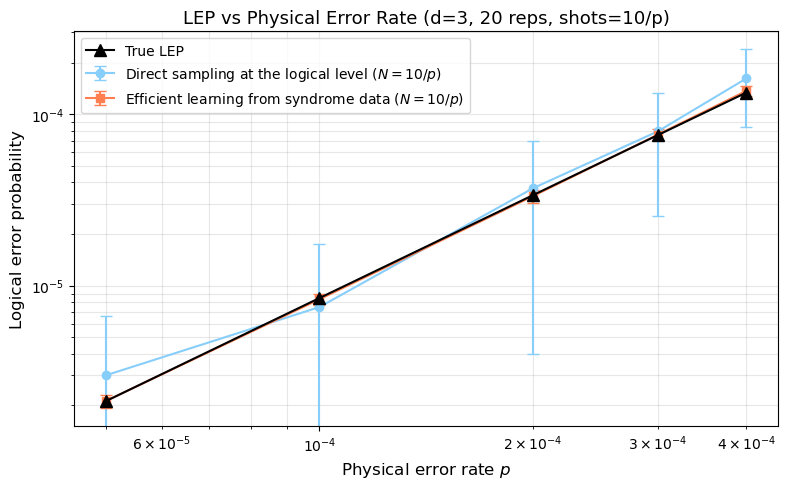

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# True LEP
ax.plot(p_values, true_leps, 'k^-', ms=8, lw=1.5, label='True LEP', zorder=3)

# Direct sampling at the logical level
s_means = [np.mean(sampled_leps[p]) for p in p_values]
s_stds = [np.std(sampled_leps[p]) for p in p_values]
ax.errorbar(p_values, s_means, yerr=s_stds, fmt='o-', color='lightskyblue',
            capsize=4, ms=6, lw=1.5, label=r'Direct sampling at the logical level ($N=10/p$)')

# Efficient learning from syndrome data
p_means = [np.mean(predicted_leps[p]) for p in p_values]
p_stds = [np.std(predicted_leps[p]) for p in p_values]
ax.errorbar(p_values, p_means, yerr=p_stds, fmt='s-', color='coral',
            capsize=4, ms=6, lw=1.5, label=r'Efficient learning from syndrome data ($N=10/p$)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$', fontsize=12)
ax.set_ylabel('Logical error probability', fontsize=12)
ax.set_title(f'LEP vs Physical Error Rate (d={d}, {n_reps} reps, shots=10/p)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## Step 4: Sample Complexity — Minimum Shots for 10% Relative Precision

Fix $p = 5 \times 10^{-5}$ and compute the true LEP from $10^7$ sampled shots.
Then subsample at increasing $N$ and measure the relative error of both
the sampled LEP and predicted LEP against this ground truth.

In [10]:
from sim_qec.pipeline import SyndromeExtractionConfig, run_syndrome_extraction
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams

p_fixed = 5e-5
subsample_factor = 4

BPLSD_PARAMS = {
    'max_iter': 5, 'bp_method': 'min_sum', 'ms_scaling_factor': 0.5,
    'schedule': 'parallel', 'lsd_method': 'lsd_e', 'lsd_order': 3,
}

# Build circuit at p = 5e-5
config_fixed = SyndromeExtractionConfig(
    num_cycles=1,
    physical_error_rate=p_fixed,
    shots=int(10 / p_fixed),
    fault_type='DEPOLARIZE1',
    circuit_error_params=CircuitErrorParams(
        p_i=1.0, p_state_p=0.8, p_m=0.9, p_CX=1.0, p_idling_gate=0.0,
    ),
)
res_fixed = run_syndrome_extraction(code, config_fixed)
h = res_fixed.check_matrix
l = res_fixed.observables_matrix
true_priors_fixed = res_fixed.true_priors

# Set up decoder
decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS)
decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors_fixed})

# True LEP from 1e7 sampled shots
num_samples_true = int(1e7)
dem_true, log_true = res_fixed.sampler.sample(shots=num_samples_true, separate_observables=True)
dem_true, log_true = dem_true.astype(int), log_true.astype(int)
corr_true = decoder.decode(dem_true)
true_lep_fixed = float(np.average(
    ((log_true + (corr_true @ l.T) % 2) % 2).any(axis=1).astype(int)
))
print(f'True LEP (from {num_samples_true:,} shots): {true_lep_fixed:.6e}')

# Subsample at increasing N
sample_sizes = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000,
                500_000, 1_000_000, 5_000_000]

results_sampled = []   # (N, lep, relative_error)
results_predicted = [] # (N, lep, relative_error)

for N in sample_sizes:
    # Fresh samples at this N
    dem_sub, log_sub = res_fixed.sampler.sample(shots=N, separate_observables=True)
    dem_sub, log_sub = dem_sub.astype(int), log_sub.astype(int)

    # Sampled LEP
    corr = decoder.decode(dem_sub)
    les = ((log_sub + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
    lep_s = float(np.average(les))
    rel_err_s = abs(lep_s - true_lep_fixed) / true_lep_fixed if true_lep_fixed > 0 else np.inf
    results_sampled.append((N, lep_s, rel_err_s))

    # Predicted LEP
    predictor = PredictPriors(dectector_samples=dem_sub, check_matrix=h, subsample=True, subsample_factor=subsample_factor)
    A_syn, stabs = predictor._build_A_matrix_syndromes()
    stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
    pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
    lep_p = predictor.predict_logical_error_efficient(
        decoder=decoder, observables_matrix=l, priors=pred_priors, max_order=4,
    )
    rel_err_p = abs(lep_p - true_lep_fixed) / true_lep_fixed if true_lep_fixed > 0 else np.inf
    results_predicted.append((N, lep_p, rel_err_p))

    print(f'N={N:>11,}  |  sampled LEP={lep_s:.4e} (err={rel_err_s:.1%})  '
          f'|  predicted LEP={lep_p:.4e} (err={rel_err_p:.1%})')

Syndrome extraction circuit scheduling for X stabilizers: [{np.int64(0): 0, np.int64(3): 2, np.int64(2): 6, np.int64(1): 7}, {np.int64(0): 1, np.int64(3): 5, np.int64(2): 3, np.int64(1): 8}, {np.int64(0): 3, np.int64(1): 4}, {np.int64(0): 4, np.int64(1): 5}]
Syndrome extraction circuit scheduling for Z stabilizers: [{np.int64(0): 1, np.int64(3): 7, np.int64(2): 0, np.int64(1): 4}, {np.int64(0): 2, np.int64(3): 8, np.int64(1): 6}, {np.int64(0): 5, np.int64(2): 1, np.int64(1): 7}, {np.int64(0): 4, np.int64(1): 3}]
True LEP (from 10,000,000 shots): 2.400000e-06
the detector shape is: (1000, 8)
N=      1,000  |  sampled LEP=0.0000e+00 (err=100.0%)  |  predicted LEP=5.0000e-300 (err=100.0%)
the detector shape is: (5000, 8)
N=      5,000  |  sampled LEP=1.0000e-03 (err=41566.7%)  |  predicted LEP=1.0011e-03 (err=41612.3%)
the detector shape is: (10000, 8)
N=     10,000  |  sampled LEP=8.0000e-04 (err=33233.3%)  |  predicted LEP=3.0934e-06 (err=28.9%)
the detector shape is: (50000, 8)
N=     

### Minimum samples for 10% relative precision

In [11]:
threshold = 0.10  # 10% relative error

N_star_sampled = None
for N, _, rel_err in results_sampled:
    if rel_err <= threshold:
        N_star_sampled = N
        break

N_star_predicted = None
for N, _, rel_err in results_predicted:
    if rel_err <= threshold:
        N_star_predicted = N
        break

print(f'True LEP = {true_lep_fixed:.4e}  (p = {p_fixed:.0e})')
print(f'Minimum shots for \u226410% relative error:')
print(f'  Sampled LEP:   N* = {N_star_sampled:,}' if N_star_sampled else '  Sampled LEP:   not reached')
print(f'  Predicted LEP: N* = {N_star_predicted:,}' if N_star_predicted else '  Predicted LEP: not reached')

True LEP = 2.4000e-06  (p = 5e-05)
Minimum shots for ≤10% relative error:
  Sampled LEP:   N* = 5,000,000
  Predicted LEP: N* = 50,000


### Convergence plot

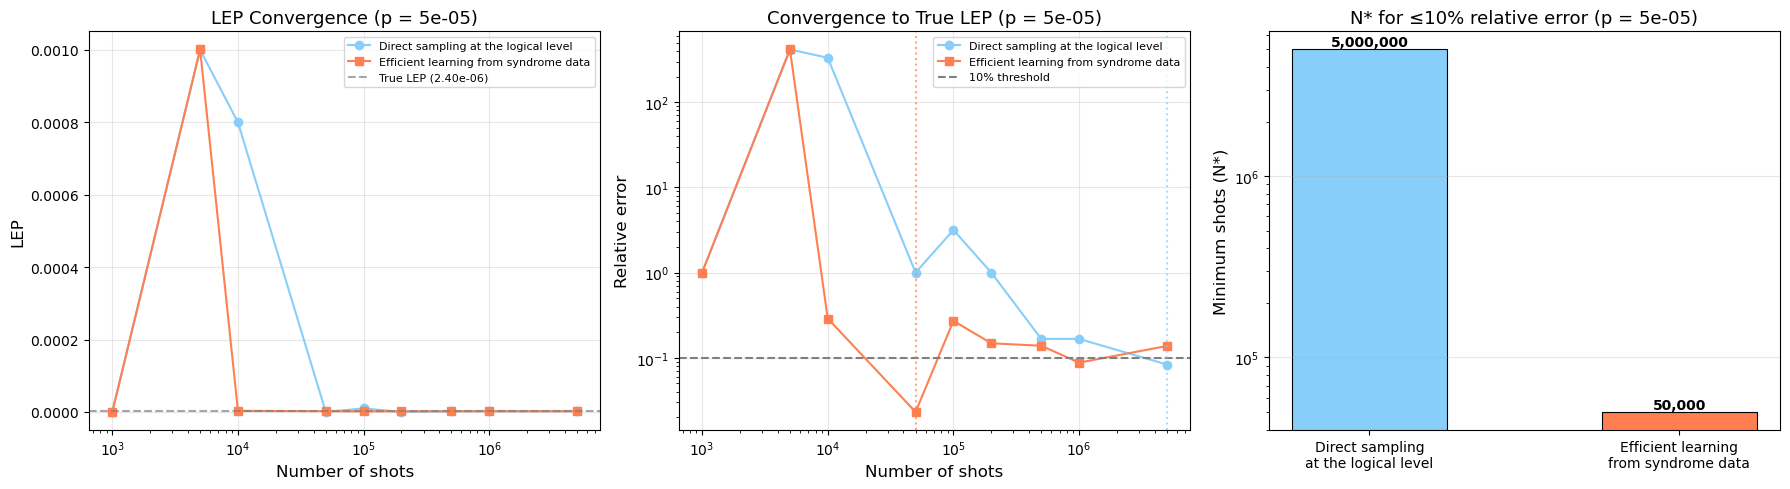

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Ns = [r[0] for r in results_sampled]

# --- Left: LEP vs sample size ---
ax = axes[0]
ax.plot(Ns, [r[1] for r in results_sampled], 'o-', color='lightskyblue', lw=1.5,
        label='Direct sampling at the logical level')
ax.plot(Ns, [r[1] for r in results_predicted], 's-', color='coral', lw=1.5,
        label='Efficient learning from syndrome data')
ax.axhline(true_lep_fixed, ls='--', color='gray', alpha=0.7,
           label=f'True LEP ({true_lep_fixed:.2e})')
ax.set_xscale('log')
ax.set_xlabel('Number of shots', fontsize=12)
ax.set_ylabel('LEP', fontsize=12)
ax.set_title(f'LEP Convergence (p = {p_fixed:.0e})', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Middle: Relative error vs sample size ---
ax = axes[1]
ax.plot(Ns, [r[2] for r in results_sampled], 'o-', color='lightskyblue', lw=1.5,
        label='Direct sampling at the logical level')
ax.plot(Ns, [r[2] for r in results_predicted], 's-', color='coral', lw=1.5,
        label='Efficient learning from syndrome data')
ax.axhline(threshold, ls='--', color='gray', lw=1.5, label='10% threshold')
if N_star_sampled:
    ax.axvline(N_star_sampled, ls=':', color='lightskyblue', alpha=0.7)
if N_star_predicted:
    ax.axvline(N_star_predicted, ls=':', color='coral', alpha=0.7)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Number of shots', fontsize=12)
ax.set_ylabel('Relative error', fontsize=12)
ax.set_title(f'Convergence to True LEP (p = {p_fixed:.0e})', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Right: Histogram of N* ---
ax = axes[2]
methods = []
n_stars = []
colors = []
if N_star_sampled:
    methods.append('Direct sampling\nat the logical level')
    n_stars.append(N_star_sampled)
    colors.append('lightskyblue')
else:
    methods.append('Direct sampling\nat the logical level')
    n_stars.append(0)
    colors.append('lightskyblue')
if N_star_predicted:
    methods.append('Efficient learning\nfrom syndrome data')
    n_stars.append(N_star_predicted)
    colors.append('coral')
else:
    methods.append('Efficient learning\nfrom syndrome data')
    n_stars.append(0)
    colors.append('coral')

bars = ax.bar(methods, n_stars, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, n_stars):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width() / 2, 0.01,
                'N/A', ha='center', va='bottom', fontsize=10, color='gray')
ax.set_ylabel('Minimum shots (N*)', fontsize=12)
ax.set_title(f'N* for \u226410% relative error (p = {p_fixed:.0e})', fontsize=13)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Step 5: Reproduce Plot (c) in This Repository (Fast Working Example)

This section reproduces the core idea of plot **(c) Savings in Sample Complexity via Learning** directly in this notebook, using the local `sim_qec` pipeline.

Quick-run profile (for validation only):
- same `max_order` for both code families
- small shot grid and few repetitions
- one fixed physical error rate

After this works, you can scale distances, shots, reps, and `max_order` to paper settings.

In [21]:
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from bposd.css import css_code

from sim_qec.codes_family.hpc_lp import rotated_surface_code_checks
from sim_qec.pipeline import SyndromeExtractionConfig, run_syndrome_extraction
from sim_qec.detector_error_models.dem_sim import CircuitErrorParams
from sim_qec.detector_error_models.circuit_decoders import BPLSD_Decoder
from sim_qec.detector_error_models.circuit_lep_prediction import PredictPriors


def build_steane_color_code():
    """Small color-code example ([[7,1,3]]) for quick validation runs."""
    H = np.array(
        [
            [1, 0, 0, 1, 0, 1, 1],
            [0, 1, 0, 1, 1, 0, 1],
            [0, 0, 1, 0, 1, 1, 1],
        ],
        dtype=int,
    )
    return css_code(H, H)


def build_surface_code(distance):
    Hx, Hz = rotated_surface_code_checks(distance)
    return css_code(Hx, Hz)


def solve_required_shots(points, target_relative_error=0.10):
    """Fit log10(err) = a*log10(shots)+b and solve for target error."""
    if len(points) < 2:
        return None

    shots = np.array([x[0] for x in points], dtype=float)
    rel_err = np.array([x[1] for x in points], dtype=float)
    mask = (shots > 0) & (rel_err > 0) & np.isfinite(rel_err)
    shots, rel_err = shots[mask], rel_err[mask]
    if len(shots) < 2:
        return None

    try:
        slope, intercept = np.polyfit(np.log10(shots), np.log10(rel_err), 1)
        if np.isclose(slope, 0.0):
            return None
        log_req = (np.log10(target_relative_error) - intercept) / slope
        req = float(10 ** log_req)
        return req if np.isfinite(req) and req >= 1 else None
    except Exception:
        return None


def compute_nstar(records, target_relative_error=0.10):
    grouped = defaultdict(lambda: defaultdict(list))
    for r in records:
        key = (r['code_family'], r['code_distance'])
        grouped[key][r['shots']].append(r)

    summary = []
    for (family, dist), shot_map in grouped.items():
        true_vals = [v['lep_true'] for vals in shot_map.values() for v in vals if v['lep_true'] is not None]
        if not true_vals:
            continue
        true_lep = float(np.mean(true_vals))
        if true_lep <= 0:
            continue

        sampled_points, predicted_points = [], []
        for shots, vals in sorted(shot_map.items()):
            s_vals = [v['lep_sampled'] for v in vals if v['lep_sampled'] is not None and np.isfinite(v['lep_sampled'])]
            p_vals = [v['lep_predicted'] for v in vals if v['lep_predicted'] is not None and np.isfinite(v['lep_predicted'])]

            if len(s_vals) > 1:
                sampled_points.append((shots, float(np.std(s_vals) / true_lep)))
            if len(p_vals) > 1:
                predicted_points.append((shots, float(np.std(p_vals) / true_lep)))

        nstar_s = solve_required_shots(sampled_points, target_relative_error=target_relative_error)
        nstar_p = solve_required_shots(predicted_points, target_relative_error=target_relative_error)
        speedup = (nstar_s / nstar_p) if (nstar_s is not None and nstar_p is not None and nstar_p > 0) else None

        summary.append(
            {
                'code_family': family,
                'code_distance': dist,
                'true_lep': true_lep,
                'nstar_sampled': nstar_s,
                'nstar_predicted': nstar_p,
                'speedup': speedup,
            }
        )

    summary.sort(key=lambda x: (x['code_family'], x['code_distance']))
    return summary

In [ ]:
# --- Fast validation config (target ~5-10 min) ---
max_order_quick = 2
p_target = 5e-3
shot_grid = [4_000, 8_000, 16_000]
n_reps_quick = 2
subsample_factor_quick = 2

# Use small set for quick validation. You can scale these later.
family_specs = [
    {'code_family': 'surface', 'code_distance': 3},
    {'code_family': 'surface', 'code_distance': 5},
    {'code_family': 'color', 'code_distance': 3},
]

BPLSD_PARAMS_QUICK = {
    'max_iter': 5,
    'bp_method': 'min_sum',
    'ms_scaling_factor': 0.5,
    'schedule': 'parallel',
    'lsd_method': 'lsd_e',
    'lsd_order': 3,
}

records_quick = []

for spec in family_specs:
    family = spec['code_family']
    dist = spec['code_distance']

    if family == 'surface':
        code_local = build_surface_code(dist)
    elif family == 'color':
        code_local = build_steane_color_code()
    else:
        raise ValueError(f'Unknown family: {family}')

    # Ensure DEM builder gets 2D ndarray checks (avoids sparse/0d indexing edge cases).
    code_local.hx = code_local.hx.toarray().astype(int) if hasattr(code_local.hx, 'toarray') else np.asarray(code_local.hx, dtype=int)
    code_local.hz = code_local.hz.toarray().astype(int) if hasattr(code_local.hz, 'toarray') else np.asarray(code_local.hz, dtype=int)

    print(f"\n=== family={family}, distance={dist}, p={p_target:.1e} ===")

    for shots in shot_grid:
        config_local = SyndromeExtractionConfig(
            num_cycles=1,
            physical_error_rate=p_target,
            shots=shots,
            num_samples_true_lep=50_000,
            fault_type='DEPOLARIZE1',
            circuit_error_params=CircuitErrorParams(
                p_i=1.0,
                p_state_p=0.8,
                p_m=0.9,
                p_CX=1.0,
                p_idling_gate=0.0,
            ),
        )

        res = run_syndrome_extraction(code_local, config_local)
        h = res.check_matrix
        l = res.observables_matrix
        true_priors = res.true_priors

        decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS_QUICK)
        decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors})

        # True LEP once per (family, distance, shots) using exact priors with same max_order.
        helper = PredictPriors(
            dectector_samples=res.dem_vals,
            check_matrix=h,
            subsample=True,
            subsample_factor=subsample_factor_quick,
        )
        true_lep = float(
            helper.predict_logical_error_efficient(
                decoder=decoder,
                observables_matrix=l,
                priors=true_priors,
                max_order=max_order_quick,
            )
        )

        for rep in range(n_reps_quick):
            dem_rep, log_rep = res.sampler.sample(shots=shots, separate_observables=True)
            dem_rep = dem_rep.astype(int)
            log_rep = log_rep.astype(int)

            # Direct sampling at logical level
            corr = decoder.decode(dem_rep)
            les = ((log_rep + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
            lep_sampled = float(np.mean(les))

            # Efficient learning from syndrome data
            predictor = PredictPriors(
                dectector_samples=dem_rep,
                check_matrix=h,
                subsample=True,
                subsample_factor=subsample_factor_quick,
            )
            A_syn, stabs = predictor._build_A_matrix_syndromes()
            stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
            pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
            lep_predicted = float(
                predictor.predict_logical_error_efficient(
                    decoder=decoder,
                    observables_matrix=l,
                    priors=pred_priors,
                    max_order=max_order_quick,
                )
            )

            records_quick.append(
                {
                    'p': p_target,
                    'shots': int(shots),
                    'code_family': family,
                    'code_distance': int(dist),
                    'lep_sampled': lep_sampled,
                    'lep_predicted': lep_predicted,
                    'lep_true': true_lep,
                }
            )

        print(f"  shots={shots:>6,} | true={true_lep:.3e} | reps={n_reps_quick}")

print(f"\nTotal records collected: {len(records_quick)}")

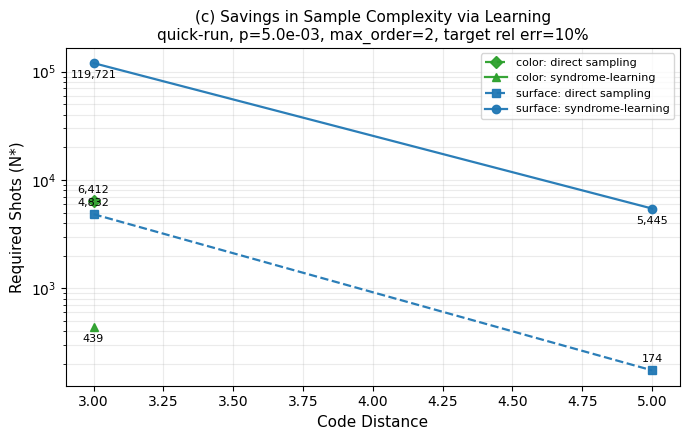


Summary (N* from log-log fit at 10% relative error):
family   distance   true_lep      N*_sampled   N*_predicted   speedup(sampled/pred)
color    3          1.018e-02   6,412        439            14.58x
surface  3          1.471e-02   4,832        119,721        0.04x
surface  5          4.372e-03   174          5,445          0.03x


In [5]:
summary_quick = compute_nstar(records_quick, target_relative_error=0.10)

# --- Plot (c)-style: savings in sample complexity ---
fig, ax = plt.subplots(figsize=(7, 4.5))

palette = {'surface': '#1f77b4', 'color': '#2ca02c'}
marker_sampled = {'surface': 's', 'color': 'D'}
marker_pred = {'surface': 'o', 'color': '^'}

for family in sorted({r['code_family'] for r in summary_quick}):
    rows = [r for r in summary_quick if r['code_family'] == family]
    if not rows:
        continue

    xs = [r['code_distance'] for r in rows]
    ys_s = [r['nstar_sampled'] for r in rows]
    ys_p = [r['nstar_predicted'] for r in rows]

    valid_s = [(x, y) for x, y in zip(xs, ys_s) if y is not None and np.isfinite(y)]
    valid_p = [(x, y) for x, y in zip(xs, ys_p) if y is not None and np.isfinite(y)]

    if valid_s:
        ax.plot(
            [x for x, _ in valid_s],
            [y for _, y in valid_s],
            linestyle='--',
            marker=marker_sampled[family],
            color=palette[family],
            lw=1.6,
            ms=6,
            alpha=0.95,
            label=f'{family}: direct sampling',
        )

    if valid_p:
        ax.plot(
            [x for x, _ in valid_p],
            [y for _, y in valid_p],
            linestyle='-',
            marker=marker_pred[family],
            color=palette[family],
            lw=1.6,
            ms=6,
            alpha=0.95,
            label=f'{family}: syndrome-learning',
        )

for row in summary_quick:
    x = row['code_distance']
    if row['nstar_sampled'] is not None:
        ax.annotate(
            f"{int(row['nstar_sampled']):,}",
            (x, row['nstar_sampled']),
            textcoords='offset points',
            xytext=(0, 6),
            ha='center',
            fontsize=8,
        )
    if row['nstar_predicted'] is not None:
        ax.annotate(
            f"{int(row['nstar_predicted']):,}",
            (x, row['nstar_predicted']),
            textcoords='offset points',
            xytext=(0, -11),
            ha='center',
            fontsize=8,
        )

ax.set_yscale('log')
ax.set_xlabel('Code Distance', fontsize=11)
ax.set_ylabel('Required Shots (N*)', fontsize=11)
ax.set_title(
    f"(c) Savings in Sample Complexity via Learning\n"
    f"quick-run, p={p_target:.1e}, max_order={max_order_quick}, target rel err=10%",
    fontsize=11,
)
ax.grid(True, which='both', alpha=0.25)
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

# --- Compact summary table ---
print('\nSummary (N* from log-log fit at 10% relative error):')
print('family   distance   true_lep      N*_sampled   N*_predicted   speedup(sampled/pred)')
for row in summary_quick:
    ns = f"{int(row['nstar_sampled']):,}" if row['nstar_sampled'] is not None else 'N/A'
    npred = f"{int(row['nstar_predicted']):,}" if row['nstar_predicted'] is not None else 'N/A'
    sp = f"{row['speedup']:.2f}x" if row['speedup'] is not None else 'N/A'
    print(f"{row['code_family']:<8} {row['code_distance']:<10} {row['true_lep']:<11.3e} {ns:<12} {npred:<14} {sp}")

## Step 6: Scalable Data Pipeline with JSON Checkpoints (Surface + Color)

This section adds a staged workflow so long experiments can be split across sessions:
1. run manageable batches and append records into JSON,
2. resume later without losing prior points,
3. regenerate a combined 3-panel figure in the style of the `combined_plots.ipynb` figure.

The same `max_order` is used for both code families.

In [6]:
import json
import os
from datetime import datetime


def build_color_code(distance):
    """Color-code constructors used in previous repo workflows."""
    if distance == 3:
        H7 = np.array(
            [
                [1, 0, 0, 1, 0, 1, 1],
                [0, 1, 0, 1, 1, 0, 1],
                [0, 0, 1, 0, 1, 1, 1],
            ],
            dtype=int,
        )
        return css_code(H7, H7)

    if distance == 5:
        faces_17 = [
            {1, 2, 3, 4},
            {1, 3, 5, 6},
            {5, 6, 9, 10},
            {7, 8, 11, 12},
            {9, 10, 13, 14},
            {11, 12, 15, 16},
            {8, 12, 16, 17},
            {3, 4, 6, 7, 10, 11, 14, 15},
        ]

        def row_from_face(face_set, n=17):
            row = np.zeros(n, dtype=int)
            for q in face_set:
                row[q - 1] = 1
            return row

        H17 = np.vstack([row_from_face(face) for face in faces_17])
        return css_code(H17, H17)

    raise ValueError(f'Unsupported color distance: {distance}. Use 3 or 5 for now.')


def _dense_css_checks(code_obj):
    code_obj.hx = code_obj.hx.toarray().astype(int) if hasattr(code_obj.hx, 'toarray') else np.asarray(code_obj.hx, dtype=int)
    code_obj.hz = code_obj.hz.toarray().astype(int) if hasattr(code_obj.hz, 'toarray') else np.asarray(code_obj.hz, dtype=int)
    return code_obj


def load_json_records(path):
    if not os.path.exists(path):
        return []
    with open(path, 'r') as f:
        content = f.read().strip()
    return json.loads(content) if content else []


def save_json_records(path, records):
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    with open(path, 'w') as f:
        json.dump(records, f, indent=2)


def run_scaling_batch_to_json(
    out_json_path,
    p_values,
    shot_grid,
    surface_distances,
    color_distances,
    n_reps,
    max_order,
    num_cycles=1,
    subsample_factor=2,
    skip_existing=True,
):
    """Run one manageable batch and append records to JSON for checkpointed workflows."""
    existing = load_json_records(out_json_path)

    existing_keys = set()
    if skip_existing:
        for r in existing:
            existing_keys.add(
                (
                    float(r['p']),
                    int(r['shots']),
                    r['code_family'],
                    int(r['code_distance']),
                    int(r['rep']),
                    int(r['max_order']),
                    int(r['num_cycles']),
                )
            )

    family_specs = (
        [{'code_family': 'surface', 'code_distance': int(d)} for d in surface_distances]
        + [{'code_family': 'color', 'code_distance': int(d)} for d in color_distances]
    )

    BPLSD_PARAMS_BATCH = {
        'max_iter': 5,
        'bp_method': 'min_sum',
        'ms_scaling_factor': 0.5,
        'schedule': 'parallel',
        'lsd_method': 'lsd_e',
        'lsd_order': 3,
    }

    new_records = []

    for p in p_values:
        for shots in shot_grid:
            for spec in family_specs:
                family = spec['code_family']
                dist = spec['code_distance']

                if family == 'surface':
                    code_local = _dense_css_checks(build_surface_code(dist))
                else:
                    code_local = _dense_css_checks(build_color_code(dist))

                config_local = SyndromeExtractionConfig(
                    num_cycles=num_cycles,
                    physical_error_rate=p,
                    shots=shots,
                    num_samples_true_lep=100_000,
                    fault_type='DEPOLARIZE1',
                    circuit_error_params=CircuitErrorParams(
                        p_i=1.0,
                        p_state_p=0.8,
                        p_m=0.9,
                        p_CX=1.0,
                        p_idling_gate=0.0,
                    ),
                )

                res = run_syndrome_extraction(code_local, config_local)
                h = res.check_matrix
                l = res.observables_matrix
                true_priors = res.true_priors

                decoder = BPLSD_Decoder(BPLSD_params=BPLSD_PARAMS_BATCH)
                decoder.set_decoder({'H': h, 'L': l, 'channel_probs': true_priors})

                helper = PredictPriors(
                    dectector_samples=res.dem_vals,
                    check_matrix=h,
                    subsample=True,
                    subsample_factor=subsample_factor,
                )
                lep_true = float(
                    helper.predict_logical_error_efficient(
                        decoder=decoder,
                        observables_matrix=l,
                        priors=true_priors,
                        max_order=max_order,
                    )
                )

                for rep in range(n_reps):
                    key = (float(p), int(shots), family, int(dist), int(rep), int(max_order), int(num_cycles))
                    if skip_existing and key in existing_keys:
                        continue

                    dem_rep, log_rep = res.sampler.sample(shots=shots, separate_observables=True)
                    dem_rep = dem_rep.astype(int)
                    log_rep = log_rep.astype(int)

                    corr = decoder.decode(dem_rep)
                    les = ((log_rep + (corr @ l.T) % 2) % 2).any(axis=1).astype(int)
                    lep_sampled = float(np.mean(les))

                    predictor = PredictPriors(
                        dectector_samples=dem_rep,
                        check_matrix=h,
                        subsample=True,
                        subsample_factor=subsample_factor,
                    )
                    A_syn, stabs = predictor._build_A_matrix_syndromes()
                    stab_eigs = predictor._get_syndrome_expectations(sample_stabs=stabs)
                    pred_priors = predictor.predict_priors(A_syn, stab_eigs, mode='rip')
                    lep_predicted = float(
                        predictor.predict_logical_error_efficient(
                            decoder=decoder,
                            observables_matrix=l,
                            priors=pred_priors,
                            max_order=max_order,
                        )
                    )

                    new_records.append(
                        {
                            'timestamp': datetime.now().isoformat(),
                            'p': float(p),
                            'shots': int(shots),
                            'code_family': family,
                            'code_distance': int(dist),
                            'rep': int(rep),
                            'num_cycles': int(num_cycles),
                            'max_order': int(max_order),
                            'lep_sampled': lep_sampled,
                            'lep_predicted': lep_predicted,
                            'lep_true': lep_true,
                            'max_rel_diff': float(abs(lep_predicted - lep_true) / lep_true) if lep_true > 0 else np.nan,
                        }
                    )

    all_records = existing + new_records
    save_json_records(out_json_path, all_records)
    print(f'Wrote {len(new_records)} new records to {out_json_path} (total={len(all_records)}).')
    return all_records

In [10]:
def get_violin_data_for_tau(records, p_to_plot, shots_to_plot):
    """Build violin inputs of tau=max relative diff grouped by p and shots."""
    grouped = defaultdict(lambda: defaultdict(list))
    for r in records:
        p = float(r['p'])
        s = int(r['shots'])
        tau = r.get('max_rel_diff', np.nan)
        if np.isfinite(tau):
            grouped[p][s].append(float(tau))

    violin = {}
    for p in p_to_plot:
        if p not in grouped:
            continue
        shot_vals, tau_vals = [], []
        for s in sorted(shots_to_plot):
            vals = grouped[p].get(int(s), [])
            vals = [v for v in vals if np.isfinite(v) and v > 0]
            if vals:
                shot_vals.append(int(s))
                tau_vals.append(vals)
        if tau_vals:
            violin[p] = (tau_vals, shot_vals)
    return violin


def shots_needed_vs_p_from_tau(records, p_to_plot, shots_to_plot, target_tau=0.8):
    """Reproduce panel (b): required shots vs p using tau interpolation."""
    violin = get_violin_data_for_tau(records, p_to_plot, shots_to_plot)
    valid_p, shots_needed = [], []

    for p in p_to_plot:
        if p not in violin:
            continue
        tau_lists, shot_pos = violin[p]
        med = np.array([np.median(v) for v in tau_lists], dtype=float)
        sh = np.array(shot_pos, dtype=float)

        mask = (med > 0) & np.isfinite(med) & (sh > 0)
        med = med[mask]
        sh = sh[mask]
        if len(med) < 2:
            continue

        order = np.argsort(med)
        med = med[order]
        sh = sh[order]

        log_tau = np.log(med)
        log_shots = np.log(sh)
        log_target = np.log(target_tau)

        log_needed = np.interp(log_target, log_tau, log_shots)
        valid_p.append(float(p))
        shots_needed.append(float(np.exp(log_needed)))

    return violin, valid_p, shots_needed


def compute_plotc_results(records, target_p=5e-4, relative_accuracy=0.10, shots_to_use=None, family_filter='surface'):
    """Reproduce panel (c): required shots vs distance at fixed p."""
    grouped = defaultdict(lambda: defaultdict(list))
    for r in records:
        if not np.isclose(float(r['p']), float(target_p), atol=1e-12):
            continue
        if family_filter is not None and r['code_family'] != family_filter:
            continue
        s = int(r['shots'])
        if shots_to_use is not None and s not in shots_to_use:
            continue
        d = int(r['code_distance'])
        grouped[d][s].append(r)

    out = {}
    for d, by_shot in grouped.items():
        true_vals = [x['lep_true'] for rows in by_shot.values() for x in rows if np.isfinite(x.get('lep_true', np.nan))]
        if not true_vals:
            continue
        true_lep = float(np.mean(true_vals))
        if true_lep <= 0:
            continue

        sampled_pts, pred_pts = [], []
        for s, rows in by_shot.items():
            svals = [x['lep_sampled'] for x in rows if np.isfinite(x.get('lep_sampled', np.nan))]
            pvals = [x['lep_predicted'] for x in rows if np.isfinite(x.get('lep_predicted', np.nan))]
            if len(svals) > 1:
                sampled_pts.append((s, float(np.std(svals) / true_lep)))
            if len(pvals) > 1:
                pred_pts.append((s, float(np.std(pvals) / true_lep)))

        out[d] = {
            'sampled': solve_required_shots(sampled_pts, target_relative_error=relative_accuracy),
            'predicted': solve_required_shots(pred_pts, target_relative_error=relative_accuracy),
        }

    return out


def plot_combined_style_from_json(
    records,
    p_to_plot,
    shots_to_plot,
    target_tau=0.8,
    relative_accuracy=0.10,
    target_p_for_c=5e-4,
    family_for_c='surface',
):
    """3-panel plot styled after combined_plots.ipynb."""
    violin_data, valid_p, shots_needed = shots_needed_vs_p_from_tau(
        records=records,
        p_to_plot=p_to_plot,
        shots_to_plot=shots_to_plot,
        target_tau=target_tau,
    )

    c_results = compute_plotc_results(
        records=records,
        target_p=target_p_for_c,
        relative_accuracy=relative_accuracy,
        shots_to_use=shots_to_plot,
        family_filter=family_for_c,
    )

    fig = plt.figure(figsize=(8, 4.4), constrained_layout=True)
    gs = fig.add_gridspec(2, 2, width_ratios=[1.2, 1.0], height_ratios=[1, 1])
    ax1 = fig.add_subplot(gs[:, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 1])

    # (a) violin
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(p_to_plot)))
    for idx, p in enumerate(p_to_plot):
        if p not in violin_data:
            continue
        v_data, v_pos = violin_data[p]
        widths = 0.5 * np.array(v_pos)
        parts = ax1.violinplot(
            v_data,
            positions=v_pos,
            vert=False,
            widths=widths,
            showmeans=False,
            showmedians=True,
            showextrema=False,
            quantiles=[[0.25, 0.75]] * len(v_data),
        )
        for pc in parts['bodies']:
            pc.set_facecolor(colors[idx])
            pc.set_alpha(0.6)
            pc.set_edgecolor('black')
            pc.set_linewidth(0.5)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.4)
        parts['cquantiles'].set_color('black')
        parts['cquantiles'].set_linestyle('--')
        parts['cquantiles'].set_linewidth(0.8)
        parts['cquantiles'].set_alpha(0.5)

        med = [np.median(v) for v in v_data]
        ax1.plot(med, v_pos, 'o-', color=colors[idx], label=f'p={p:.1e}', alpha=0.8, markersize=4)

    ax1.axvline(x=target_tau, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Target $\\tau={target_tau}$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Max Relative Difference ($\\tau$)', fontsize=8)
    ax1.set_ylabel('Sample Size', fontsize=8)
    ax1.legend(fontsize=7, loc='upper right', framealpha=0.9)
    ax1.grid(True, which='both', ls='-', alpha=0.2)
    ax1.tick_params(labelsize=7)

    # (b) shots vs p
    fit_min = fit_max = None
    if valid_p:
        ax2.plot(valid_p, shots_needed, 'o', color='red', markersize=5, label='Shot number')
        if len(valid_p) >= 2:
            try:
                slope, intercept = np.polyfit(np.log(valid_p), np.log(shots_needed), 1)
                ref_p = np.logspace(np.log10(min(valid_p)), np.log10(max(valid_p)), 200)
                fit_y = np.exp(intercept) * ref_p ** slope
                fit_min = float(np.min(fit_y))
                fit_max = float(np.max(fit_y))
                ax2.loglog(ref_p, fit_y, 'b-', linewidth=1.2, label=f'Fit: $N \\sim p^{{{slope:.2f}}}$')
            except Exception:
                pass

        y_min = float(np.min(shots_needed))
        y_max = float(np.max(shots_needed))
        y_lo = min([y_min] + ([fit_min] if fit_min is not None else [])) * 0.7
        y_hi = max([y_max] + ([fit_max] if fit_max is not None else [])) * 2.5
        ax2.set_ylim(max(y_lo, 1e-12), y_hi)
        if len(valid_p) >= 2:
            ax2.set_xlim(min(valid_p) * 0.85, max(valid_p) * 1.15)
        else:
            p0 = valid_p[0]
            ax2.set_xlim(p0 * 0.8, p0 * 1.25)
        ax2.margins(x=0.06)

        for i, (p, n) in enumerate(zip(valid_p, shots_needed)):
            if i == len(valid_p) - 1:
                ax2.annotate(
                    f'{int(n):,}', (p, n), textcoords='offset points', xytext=(2.0, 5), ha='right', va='bottom', fontsize=6,
                    bbox=dict(facecolor='white', alpha=0.85, edgecolor='none', pad=0.2),
                )
            else:
                ax2.annotate(f'{int(n):,}', (p, n), textcoords='offset points', xytext=(6, 0), ha='left', va='center', fontsize=6)

    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_ylabel('Shots Needed', fontsize=8)
    ax2.legend(fontsize=7, framealpha=0.9, loc='upper right')
    ax2.grid(True, which='both', ls='-', alpha=0.2)
    ax2.tick_params(labelsize=7)

    # (c) savings vs distance
    distances = sorted(c_results.keys())
    sampled_vals = [c_results[d]['sampled'] for d in distances if c_results[d]['sampled'] is not None]
    sampled_ds = [d for d in distances if c_results[d]['sampled'] is not None]
    pred_vals = [c_results[d]['predicted'] for d in distances if c_results[d]['predicted'] is not None]
    pred_ds = [d for d in distances if c_results[d]['predicted'] is not None]

    if sampled_ds:
        ax3.plot(sampled_ds, sampled_vals, marker='s', markersize=6, linewidth=1.5, color='#1f77b4', linestyle='--', alpha=0.9,
                 label='Direct sampling at the logical level', markeredgewidth=1.0, markeredgecolor='#0c5aa6')
    if pred_ds:
        ax3.plot(pred_ds, pred_vals, marker='o', markersize=6, linewidth=1.5, color='#ff7f0e', linestyle='-', alpha=0.9,
                 label='Efficient learning from syndrome data', markeredgewidth=1.0, markeredgecolor='#cc6600')

    all_y = [v for v in (sampled_vals + pred_vals) if v is not None and np.isfinite(v)]
    if all_y:
        y_min = float(np.min(all_y))
        y_max = float(np.max(all_y))
        ax3.set_ylim(max(y_min / 2.0, 1e-12), y_max * 15.0)

    if distances:
        ax3.set_xlim(min(distances) - 0.8, max(distances) + 0.8)

    for d, s in zip(sampled_ds, sampled_vals):
        ax3.annotate(f'{int(s):,}', (d, s), textcoords='offset points', xytext=(0, 7), ha='center', va='bottom', fontsize=6, fontweight='bold')
    for d, s in zip(pred_ds, pred_vals):
        ax3.annotate(f'{int(s):,}', (d, s), textcoords='offset points', xytext=(0, 7), ha='center', va='bottom', fontsize=6, fontweight='bold')

    ax3.set_yscale('log')
    ax3.set_title('(c) Savings in Sample Complexity via Learning', fontsize=8, fontweight='bold', pad=6)
    ax3.set_xlabel('Code Distance', fontsize=8)
    ax3.set_ylabel('Shots Needed', fontsize=8)
    ax3.set_xticks(distances)
    ax3.set_xticklabels(distances)
    ax3.legend(fontsize=7, framealpha=0.95, loc='upper left', bbox_to_anchor=(0.02, 0.98))
    ax3.grid(True, which='both', ls='-', alpha=0.2)
    ax3.tick_params(labelsize=7)

    # aligned top titles for (a), (b)
    fig.canvas.draw()
    pos1 = ax1.get_position()
    pos2 = ax2.get_position()
    title_y = min(max(pos1.y1, pos2.y1) + 0.01, 0.995)
    fig.text((pos1.x0 + pos1.x1) / 2, title_y, '(a) Sample Complexity vs Accuracy', ha='center', va='bottom', fontsize=8, fontweight='bold')
    fig.text((pos2.x0 + pos2.x1) / 2, title_y, '(b) Sample Complexity vs Error Rate', ha='center', va='bottom', fontsize=8, fontweight='bold')

    fig.align_ylabels([ax1, ax2, ax3])
    plt.show()

    # compact table for both families at target p
    print('\nN* summary at target p:')
    print('family   d   N*_sampled   N*_predicted   speedup')
    for fam in sorted({r['code_family'] for r in records}):
        fam_results = compute_plotc_results(
            records=records,
            target_p=target_p_for_c,
            relative_accuracy=relative_accuracy,
            shots_to_use=shots_to_plot,
            family_filter=fam,
        )
        for d in sorted(fam_results.keys()):
            ns = fam_results[d]['sampled']
            npd = fam_results[d]['predicted']
            sp = (ns / npd) if (ns is not None and npd is not None and npd > 0) else None
            ns_txt = f"{int(ns):,}" if ns is not None else 'N/A'
            np_txt = f"{int(npd):,}" if npd is not None else 'N/A'
            sp_txt = f"{sp:.2f}x" if sp is not None else 'N/A'
            print(f"{fam:<8} {d:<3} {ns_txt:<12} {np_txt:<14} {sp_txt}")

In [ ]:
# --- Scalable config (editable) ---
SCALING_JSON = 'scaling_records_qec.json'

# Keep max_order identical across families.
MAX_ORDER_SCALING = 3
NUM_CYCLES_SCALING = 1
SUBSAMPLE_FACTOR_SCALING = 2

# First do color code here only, because surface code need more time.
P_VALUES_SCALING = [2e-5, 5e-5, 1e-4, 2e-4, 5e-4]
SHOTS_SCALING = [10_000, 30_000, 100_000, 300_000, 1_000_000]
SURFACE_DIST_SCALING = []
COLOR_DIST_SCALING = [3, 5]
N_REPS_SCALING = 20

records_scaling = run_scaling_batch_to_json(
    out_json_path=SCALING_JSON,
    p_values=P_VALUES_SCALING,
    shot_grid=SHOTS_SCALING,
    surface_distances=SURFACE_DIST_SCALING,
    color_distances=COLOR_DIST_SCALING,
    n_reps=N_REPS_SCALING,
    max_order=MAX_ORDER_SCALING,
    num_cycles=NUM_CYCLES_SCALING,
    subsample_factor=SUBSAMPLE_FACTOR_SCALING,
    skip_existing=True,
)

print(f'Loaded records in memory: {len(records_scaling)}')

In [ ]:
def print_text_table(headers, rows, max_col_widths=None):
    widths = [len(str(h)) for h in headers]
    for row in rows:
        for i, value in enumerate(row):
            widths[i] = max(widths[i], len(str(value)))
    if max_col_widths is not None:
        widths = [min(w, max_col_widths[i]) if i < len(max_col_widths) and max_col_widths[i] else w for i, w in enumerate(widths)]

    def fmt(value, idx):
        text = str(value)
        if max_col_widths is not None and idx < len(max_col_widths) and max_col_widths[idx] and len(text) > max_col_widths[idx]:
            text = text[: max_col_widths[idx] - 3] + '...'
        return text.ljust(widths[idx])

    header_line = ' | '.join(fmt(h, i) for i, h in enumerate(headers))
    sep_line = '-+-'.join('-' * widths[i] for i in range(len(headers)))
    print(header_line)
    print(sep_line)
    for row in rows:
        print(' | '.join(fmt(value, i) for i, value in enumerate(row)))


records_loaded = load_json_records(SCALING_JSON)
print(f'Records loaded from {SCALING_JSON}: {len(records_loaded)}')

if records_loaded:
    expected_cols = ['code_family', 'code_distance', 'p', 'shots', 'rep', 'max_order', 'num_cycles']
    records_indexed = []
    for record in records_loaded:
        normalized = dict(record)
        for col in expected_cols:
            normalized.setdefault(col, None)
        records_indexed.append(normalized)

    print('\nCounts by family and distance:')
    rows = []
    pairs = sorted({(r['code_family'], int(r['code_distance'])) for r in records_indexed})
    for family, dist in pairs:
        count = sum(1 for r in records_indexed if r['code_family'] == family and int(r['code_distance']) == dist)
        rows.append((family, dist, count))
    print_text_table(['family', 'distance', 'count'], rows)

    print('\nCounts by family, p, and distance:')
    rows = []
    triples = sorted({(r['code_family'], float(r['p']), int(r['code_distance'])) for r in records_indexed})
    for family, p_val, dist in triples:
        count = sum(1 for r in records_indexed if r['code_family'] == family and float(r['p']) == p_val and int(r['code_distance']) == dist)
        rows.append((family, f'{p_val:.1e}', dist, count))
    print_text_table(['family', 'p', 'distance', 'count'], rows)

    print('\nCounts by family, distance, and shots:')
    rows = []
    quads = sorted({(r['code_family'], int(r['code_distance']), int(r['shots'])) for r in records_indexed})
    for family, dist, shots in quads:
        count = sum(1 for r in records_indexed if r['code_family'] == family and int(r['code_distance']) == dist and int(r['shots']) == shots)
        rows.append((family, dist, f'{shots:,}', count))
    print_text_table(['family', 'distance', 'shots', 'count'], rows)

    print('\nCoverage pivot: number of records per (family, distance) x shots')
    shots_axis = sorted({int(r['shots']) for r in records_indexed})
    header = ['family', 'distance'] + [f'{s:,}' for s in shots_axis]
    rows = []
    for family, dist in pairs:
        row = [family, dist]
        for shots in shots_axis:
            count = sum(1 for r in records_indexed if r['code_family'] == family and int(r['code_distance']) == dist and int(r['shots']) == shots)
            row.append(count)
        rows.append(row)
    print_text_table(header, rows)

    print('\nUnique config summary:')
    rows = []
    for family, dist in pairs:
        matching = [r for r in records_indexed if r['code_family'] == family and int(r['code_distance']) == dist]
        p_values = sorted({float(r['p']) for r in matching})
        shots_values = sorted({int(r['shots']) for r in matching})
        reps = len({int(r['rep']) for r in matching if r['rep'] is not None})
        max_order = matching[0]['max_order']
        num_cycles = matching[0]['num_cycles']
        rows.append((family, dist, ', '.join(f'{p:.1e}' for p in p_values), ', '.join(f'{s:,}' for s in shots_values), reps, max_order, num_cycles))
    print_text_table(['family', 'distance', 'p_values', 'shots_values', 'reps', 'max_order', 'num_cycles'], rows, max_col_widths=[None, None, 32, 32, None, None, None])
else:
    print('No records found yet. Run the batch cell first.')

Records loaded from scaling_records_qec.json: 1006


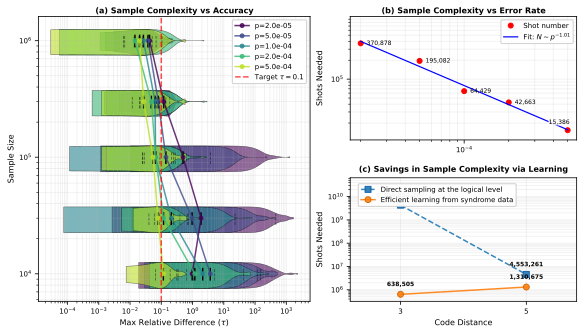


N* summary at target p:
family   d   N*_sampled   N*_predicted   speedup
color    3   4,304,864,767 638,505        6742.09x
color    5   4,553,261    1,310,675      3.47x


In [26]:
# --- Recreate combined-style 3-panel figure from JSON records ---
records_loaded = load_json_records(SCALING_JSON)
print(f'Records loaded from {SCALING_JSON}: {len(records_loaded)}')

plot_combined_style_from_json(
    records=records_loaded,
    p_to_plot=P_VALUES_SCALING,
    shots_to_plot=SHOTS_SCALING,
    target_tau=0.1,
    relative_accuracy=0.10,
    target_p_for_c=5e-5,
    family_for_c='color',
)